In [119]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


class Quantiles(nn.Module):
    def __init__(self, taus):
        super().__init__()
        self.taus = torch.tensor(taus, dtype=torch.float32)
        N = len(taus)
        # Initialize theta as a learnable parameter
        self.theta = nn.Parameter(torch.zeros(N))

    @staticmethod
    def _HL(u, kappa):
        delta = (u.abs() <= kappa).float()
        return delta * (u ** 2 / 2) + (1 - delta) * (kappa * (u.abs() - kappa / 2))

    @staticmethod
    def _rho_tau(u, tau, kappa=1.0):
        delta = (u < 0).float()
        if kappa == 0:
            return (tau - delta).abs() * u.abs()
        else:
            return (tau - delta).abs() * Quantiles._HL(u, kappa)

    def forward(self, xs):
        # xs: input samples, shape (num_samples,)
        loss = 0
        for i, tau in enumerate(self.taus):
            loss += self._rho_tau(xs - self.theta[i], tau, kappa=1).mean()
        return loss

    def get_quantiles(self, samples, loops=2000, lr=0.05):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        xs = torch.tensor(samples, dtype=torch.float32)
        for _ in range(loops):
            optimizer.zero_grad()
            loss = self.forward(xs)
            loss.backward()
            optimizer.step()
        return self.theta.detach().numpy()


class MixtureOfGaussians:
    def __init__(self, pis, mus, sigmas):
        self.pis = np.array(pis)
        self.mus = np.array(mus)
        self.sigmas = np.array(sigmas)

    def draw_samples(self, n):
        samples = np.empty(n)
        for i in range(n):
            idx = np.random.multinomial(1, self.pis).argmax()
            samples[i] = np.random.normal(self.mus[idx], self.sigmas[idx])
        return samples

    def pdf(self, x):
        return np.sum([pi * np.exp(-0.5 * ((x - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
                       for pi, mu, s in zip(self.pis, self.mus, self.sigmas)], axis=0)


# Set up mixture
MoG = MixtureOfGaussians(pis=[1/3, 1/3, 1/3], mus=[-3, 0, 5], sigmas=[2, 1, 2])
xs = np.linspace(-11, 11, num=200)
ys = MoG.pdf(xs)

# Quantile estimation
N = 30
taus = [i / (2 * N) for i in range(0, 2 * N + 1)]
Q = Quantiles(taus)

samples = MoG.draw_samples(10000)
qs = Q.get_quantiles(samples, loops=2000)

# Plot
# plt.plot(xs, ys)
# for q in qs[::2]:
#     plt.plot([q, q], [0, MoG.pdf(q)], 'black')
# plt.plot(qs[1::2], np.zeros_like(qs[1::2]), 'or')
# plt.savefig('quantiles.svg', bbox_inches='tight')
# plt.show()

In [114]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

def normal(S=1, mu=0, sigma=1):
    return np.random.normal(mu, sigma, S)

def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

runs = 1
n = len(taus)
total_episodes = 200_000
save_skip = 200
learning_rate = 0.8
gamma = 1.0

# reward + gamma * np.max(qtable[new_state]) - qtable[state, action]
# qtable[state, action] += lr * delta

def run_simple():
    thetas = np.zeros((runs, total_episodes//save_skip, n))
    tau = (np.arange(n) + 0.5) / n
    
    for run in (range(runs)):
        theta = np.zeros(n)
        lr = learning_rate
        
        for k in tqdm(range(total_episodes)):
            if k % 5000 == 0: lr *= 0.5
            
            Ttheta = MoG.draw_samples(1) + gamma * np.zeros(n) # No future state
            u = ((Ttheta[:, None] - theta[None, :])).mean(0)

            if True: rho = -np.abs(tau - (u < 0)) * du_huber(u)
            else:         rho = -(tau - (u < 0))
            theta -= lr * rho
            
            if k % save_skip == 0:
                thetas[run, k//save_skip] = theta.copy()
    return thetas

ts = run_simple()

100%|██████████| 200000/200000 [00:10<00:00, 18361.63it/s]


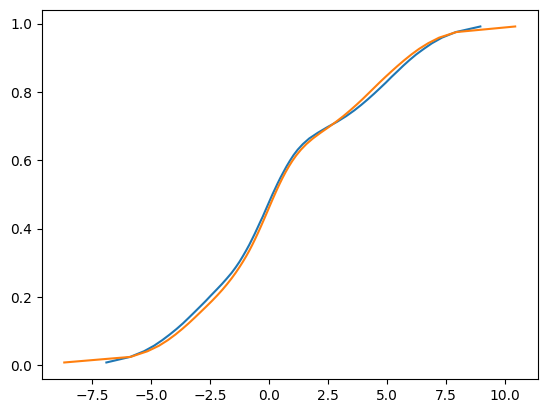

In [134]:
tau = (np.arange(n) + 0.5) / n

plt.plot(np.quantile(np.sort(MoG.draw_samples(100000)),tau), tau)
plt.plot(qs, tau)
# plt.plot(qss, tau)
# plt.plot(ts[0,-1], tau)

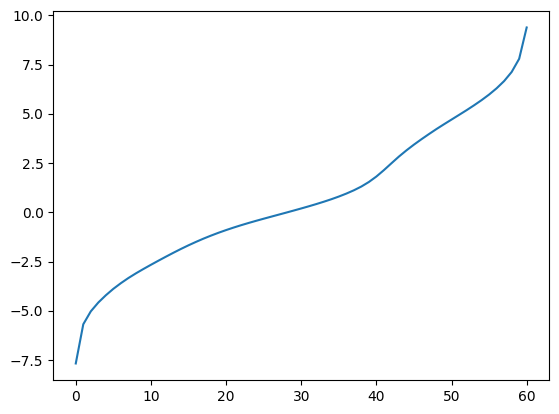

In [91]:
plt.plot(qs)